### Development of the Metric Scoring of GB1 Dataset
To answer the RQ1

#### Load Libaries needed and load data.


In [1]:
from numba import prange, njit
from models.single_mutant_walker import SingleMutantWalker
from matplotlib import pyplot as plt
import seaborn as sns

import time
from tqdm.auto import tqdm

/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np
import pandas as pd

from data.gb1_data import load_gb1_dataframe

df  = load_gb1_dataframe()
df_train = df[df['split'] == 'train']
print(f"Number of training samples: {len(df_train)}")

# Keep sequences as strings for mutation and distance calculations.
train_sequences = df_train['sequence'].astype(str).tolist()
train_set = set(train_sequences)
train_array = np.array([list(seq) for seq in train_sequences], dtype='U1')
print(f"Number of unique sequences in training set: {len(train_set)}")

/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Number of training samples: 16244
Number of unique sequences in training set: 16244


In [12]:
# Define Functions to compute min_hamming distance
@njit(parallel=True)
def min_hamming_distance(X_test, X_train):
    n_seqs = X_test.shape[0]
    n_train = X_train.shape[0]
    seq_len = X_test.shape[1]
    min_dists = np.empty(n_seqs, dtype=np.int16)

    for i in prange(n_seqs):
        best = seq_len + 1
        for j in range(n_train):
            d = 0
            for k in range(seq_len):
                if X_test[i, k] != X_train[j, k]:
                    d += 1
                    if d >= best:
                        break
            if d < best:
                best = d
        min_dists[i] = best
    return min_dists

# Assing Labels accoring to the hamming distances:
def assign_labels(min_dists):
    bins = [0, 3, 7, 10, 15, 20, np.inf]
    labels = ['near', 'close', 'medium', 'far', 'very_far', 'distant']
    indices = np.digitize(min_dists, bins)
    named_labels = np.array(labels)[indices - 1]
    print(f"Label distribution: {pd.Series(named_labels).value_counts()}")
    return named_labels


In [3]:
alphabet = 'ACDEFGHIKLMNPQRSTVWY'
seq_length = len(df_train['sequence'].iloc[0])
smw = SingleMutantWalker(alphabet, seq_length)

def select_random_sequence(train_sequences):
    index = np.random.randint(len(train_sequences))
    return train_sequences[index]

def mutate_sequence(smw, n_mutations, train_set, train_sequences):
    sequences = []
    seed = select_random_sequence(train_sequences)
    for _ in range(n_mutations):
        seed = smw.mutate_sequence(seed)
        if seed not in train_set:
            sequences.append(seed)
    return sequences

In [22]:
datset_size = 56000
n_mutations_list = np.array([1, 3, 5, 6, 8, 10, 20, 40])
generated_sequences = {
    'sequence': [],
    'min_hamming_distance': [],
}

def encode_sequence(sequence):
    return np.array(list(sequence), dtype='U1')

def generate_sequences(smw, n_mutations_list, dataset_size, train_set, train_sequences, train_array):
    t = tqdm(total=dataset_size, desc="Generating Sequences")

    while(dataset_size > len(generated_sequences['sequence'])):
        #print(f"Generated {len(generated_sequences['sequence'])}/{dataset_size} sequences")
        n_mutations = np.random.choice(n_mutations_list)
        mutated_seqs = mutate_sequence(smw, n_mutations, train_set, train_sequences)
        for seq in mutated_seqs:
            generated_sequences['sequence'].append(seq)
            generated_sequences['min_hamming_distance'].append(min_hamming_distance(encode_sequence(seq)[None, :], train_array)[0])
        time.sleep(0.1)  # Sleep to allow tqdm to update
        t.update(len(generated_sequences['sequence']) - t.n)  # Update tqdm with the number of new sequences generated
    print(f"Generated {len(generated_sequences['sequence'])} sequences")
    
generate_sequences(smw, n_mutations_list, datset_size, train_set, train_sequences, train_array)
df_generated = pd.DataFrame(generated_sequences)
print(df_generated.head())

Generating Sequences: 56022it [41:30, 22.49it/s]                             

Generated 56022 sequences
                                            sequence  min_hamming_distance
0  QYKLILNGKTLKGETTGEAVDAATAEKKFKQYANDNGVDGEHTYDD...                     1
1  QYKLILNGKTPKGETTGEAVDAATAEKKFKQYANDNGVDGEHTYDD...                     2
2  QYKLILNGKTPKGETTGEAVDAATAEKKFKQYANDNGVDGEHTYDD...                     3
3  QYKLILNGKTPKGETTGEAVDAATAEKKFKQYANDNGVDGEHVYDD...                     4
4  QYKLILNGKTPKGETTGEAVDAATAEKKFKQYANDNGVDPEHVYDD...                     5


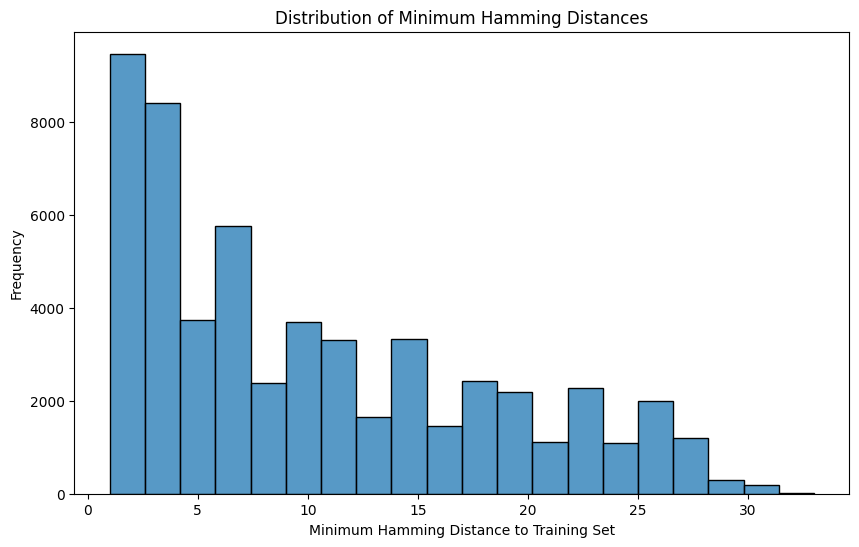

In [23]:
df_generated.to_csv('gb1_generated_sequences.csv', index=False)
plt.figure(figsize=(10, 6))
sns.histplot(df_generated['min_hamming_distance'], bins=20, kde=False)
plt.title('Distribution of Minimum Hamming Distances')
plt.xlabel('Minimum Hamming Distance to Training Set')
plt.ylabel('Frequency')
plt.show()

In [4]:
# Add oracle scores
from models.oracle import Oracle_GB1

df_generated = pd.read_csv('gb1_generated_sequences.csv')

token_to_idx = {token: idx for idx, token in enumerate(alphabet)}
print(seq_length)
oracle = Oracle_GB1(L=1100, token_to_idx=token_to_idx, seed=42)
print(f'size of generated sequences: {len(df_generated)}')
df_generated['oracle_score'] = oracle.score_batch(df_generated['sequence'].tolist())
df_generated.to_csv('gb1_generated_sequences.csv', index=False)

55
size of generated sequences: 56022


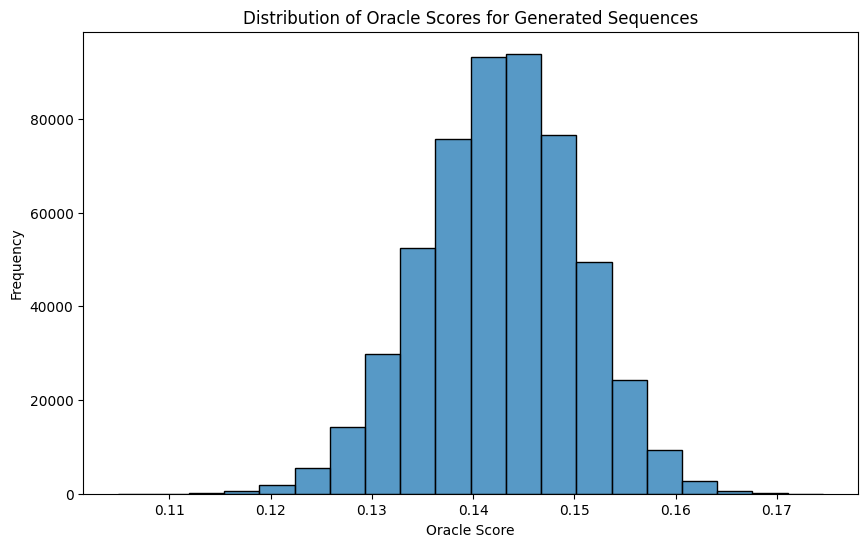

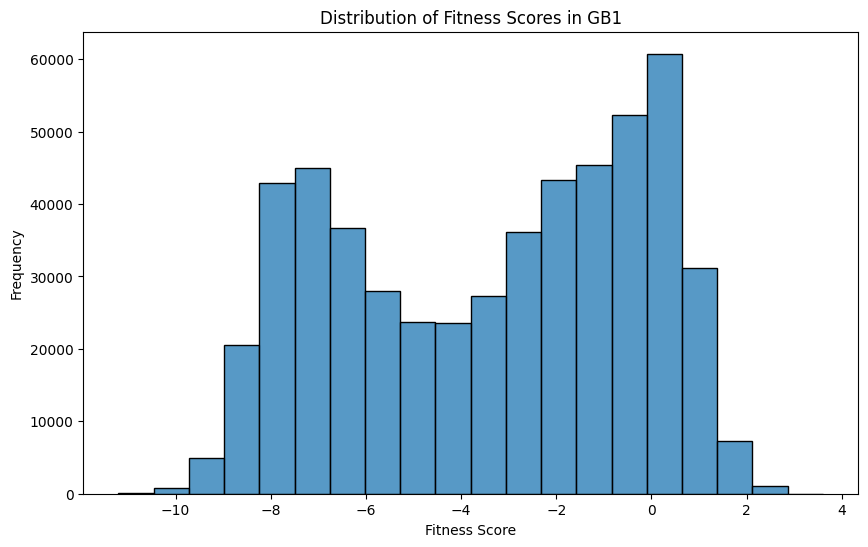

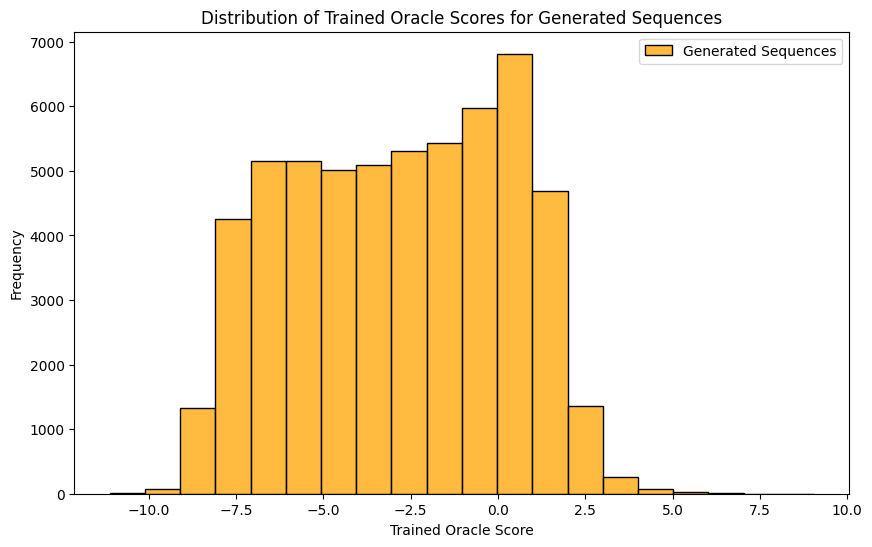

In [7]:
df['oracle_score'] = oracle.score_batch(df['sequence'].tolist())

plt.figure(figsize=(10, 6))
sns.histplot(df['oracle_score'], bins=20, kde=False)
plt.title('Distribution of Oracle Scores for Generated Sequences')
plt.xlabel('Oracle Score')
plt.ylabel('Frequency')
plt.show()

# plot distribution of real scores of df_train
plt.figure(figsize=(10, 6))
sns.histplot(df['binding_scores'], bins=20, kde=False)
plt.title('Distribution of Fitness Scores in GB1')
plt.xlabel('Fitness Score')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df_generated['oracle_score_trained'], bins=20, kde=False, color='orange', label='Generated Sequences')
plt.title('Distribution of Trained Oracle Scores for Generated Sequences')
plt.xlabel('Trained Oracle Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [5]:
df.head(5)

,sequence,binding_scores,split,cluster,distance_to_seed
0,AAKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,-3.145154,test_c,0,4
1,ACKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,-1.867676,test_c,0,4
2,ADKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,-5.270800,test_c,0,4
3,AEKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,-5.979498,test_c,0,4
4,AFKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,0.481923,test_c,0,4


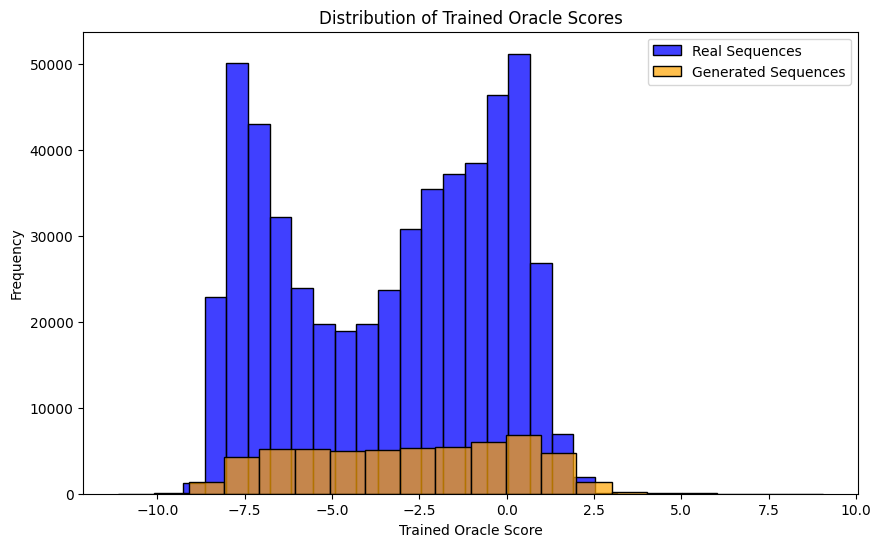

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from assets.data_ops import encode_sequence as encode_sequence_idx, one_hot_encode_sequence

## Train the oracle on the whole dataset
oracle_trained = Oracle_GB1(L=1100, token_to_idx=token_to_idx, seed=42)
for param in oracle_trained.parameters():
    param.requires_grad = True
train_data = list(zip(df['sequence'].tolist(), df['binding_scores'].tolist()))

def build_oracle_dataset(train_data, token_to_idx):
    X = np.stack([
        one_hot_encode_sequence(
            encode_sequence_idx(seq, token_to_idx),
            num_tokens=len(token_to_idx)
        )
        for seq, _ in train_data
    ])
    y = np.asarray([score for _, score in train_data], dtype=np.float32)
    return TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )

def train_oracle(oracle, train_data, token_to_idx, epochs=100):
    optimizer = torch.optim.Adam(oracle.parameters(), lr=0.001)
    train_dataset = build_oracle_dataset(train_data, token_to_idx)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    criterion = torch.nn.MSELoss()
    for epoch in range(epochs):
        oracle.train_epoch(train_loader, optimizer, criterion)

train_oracle(oracle_trained, train_data, token_to_idx, epochs=100)

df['oracle_score_trained'] = oracle_trained.score_batch(df['sequence'].tolist())
df_generated['oracle_score_trained'] = oracle_trained.score_batch(df_generated['sequence'].tolist())

plt.figure(figsize=(10, 6))
sns.histplot(df['oracle_score_trained'], bins=20, kde=False, color='blue', label='Real Sequences')
sns.histplot(df_generated['oracle_score_trained'], bins=20, kde=False, color='orange', label='Generated Sequences', alpha=0.7)
plt.title('Distribution of Trained Oracle Scores')
plt.xlabel('Trained Oracle Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()




In [34]:
# Score sequences with Random Forest
from models.random_forest import GB1RandomForest
rf = GB1RandomForest()
rf.fit(train_sequences, df_train['fitness'])
df_generated['rf_score'] = df_generated['sequence'].apply(rf.predict)

ImportError: cannot import name 'GB1RandomForest' from 'models.random_forest' (/Users/meier/Documents/MasterThesis/models/random_forest.py)